# Comparative Time Series Analysis of SARIMA dan XGBoost Models for Food Raw Material Import Value

## Business Understanding

Predicting the import value of 5 food raw material commodities group based on 2-digit HS Codes:
* HS 04 (Milk, Butter, and egg)
* HS 07 (Vegetables)
* HS 10 (Cereals)
* HS 12 (Oil seeds and oleaginous fruits)
* HS 17 (Sugars and sugar confectionery)

Background:
* Reliance of F&B businesses in Indonesia on imported food raw materials
* Fluctuations on import values impact production costs and business profit margins
* USD values ​​reflect the actual financial burden faced by businesses
* A need to understand future import value trends to formulate optimal procurement strategies

## Data Understanding 1 (Raw Data)

Import value data was obtained from BPS for the period January 2014 - May 2026, in the form of monthly data by HS code.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import matplotlib.ticker as ticker
import warnings
import pmdarima as pm

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

### Load data

In [2]:
df_2014_2016 = pd.read_excel('https://raw.githubusercontent.com/evelinn11/food-commodity-import-forecasting/main/data/bps_2014_2016.xlsx', header=None)
df_2014_2016.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,"Impor HS 2 Digit Tahun 2016,2015,2014",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Bulan,[01] Januari,[02] Februari,[03] Maret,[04] April,[05] Mei,[06] Juni,[07] Juli,[08] Agustus,[09] September,[10] Oktober,[11] November,[12] Desember,Totals
2,Kode HS,Tahun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[04] Produk susu; telur unggas; madu alam; pro...,2014,NaN,77115100.00,107389161.00,136648208.00,159130719.00,127602341.00,148197241.00,77491722.00,104288352.00,131981821.00,113795305.00,84121259.00,106461996.00,1374223225.00
4,NaN,2015,NaN,66196252.00,95365181.00,95238110.00,88797372.00,84483370.00,94572152.00,38972506.00,76282971.00,65779346.00,75840941.00,65230271.00,64948391.00,911706863.00


In [3]:
df_2017_2021 = pd.read_excel('https://raw.githubusercontent.com/evelinn11/food-commodity-import-forecasting/main/data/bps_2017_2021.xlsx', header=None)
df_2017_2021.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,"Impor HS 2 Digit Tahun 2021,2020,2019,2018,2017",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Bulan,[01] Januari,[02] Februari,[03] Maret,[04] April,[05] Mei,[06] Juni,[07] Juli,[08] Agustus,[09] September,[10] Oktober,[11] November,[12] Desember,Totals
2,Kode HS,Tahun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[04] Produk susu; telur unggas; madu alam; pro...,2017,NaN,63362910.00,91220204.00,85710820.00,78726828.00,93870008.00,68304940.00,66217605.00,96757767.00,71408568.00,94076666.00,91951948.00,88909186.00,990517450.00
4,NaN,2018,NaN,71438715.00,79305967.00,82470785.00,99433194.00,95071200.00,54367379.00,51626178.00,100195264.62,75976656.00,94035106.00,100206250.00,110352550.00,1014479244.62


In [4]:
df_2022_2026 = pd.read_excel('https://raw.githubusercontent.com/evelinn11/food-commodity-import-forecasting/main/data/bps_2022_2026.xlsx', header=None)
df_2022_2026.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,"Impor HS 2 Digit Tahun 2026,2025,2024,2023,2022",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Bulan,[01] Januari,[02] Februari,[03] Maret,[04] April,[05] Mei,[06] Juni,[07] Juli,[08] Agustus,[09] September,[10] Oktober,[11] November,[12] Desember,Totals
2,Kode HS,Tahun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[04] Milk butter and egg,2022,NaN,86826504.00,136636357.00,199833604.00,174331585.00,166313771.00,185730922.00,134834632.00,242908259.00,162021759.00,160142502.00,173576851.00,166063105.00,1989219851.00
4,NaN,2023,NaN,110054343.00,133614861.00,144031902.00,131517410.00,151500355.00,126588557.00,123191572.00,135785340.00,102458609.00,97567270.00,117008582.00,101009224.00,1474328025.00


Understanding Results
* These data still have a format that is less than ideal for time series analysis.
* Data is grouped per HS Code, then there are 3 rows per year.
* Columns for January-December are arranged horizontally and added with a 'Totals' column at the end
* There is a 'Totals' row at the bottom that needs to be removed

## Data Preparation 1 (Reshape Raw Data)

### Reshape

In [5]:
def parse_bps_file(filepath):
  df = pd.read_excel(filepath, header=None)

  # Used data row
  df = df.iloc[3:-1].reset_index(drop=True)

  # Forward fill cells which are merged in excel
  df[0] = df[0].ffill()

  # Extract HS_Code from the first column
  df['HS_Code'] = df[0].str.extract(r'\[(\d+)\]')

  # Rename month and year columns
  month_cols = {3:'01', 4:'02', 5:'03', 6:'04', 7:'05', 8:'06', 9:'07', 10:'08', 11:'09', 12:'10', 13:'11', 14:'12'}
  df = df.rename(columns={1: 'Year', **month_cols})

  # Melt the dataframe to long format
  df_long = df.melt(
      id_vars=['HS_Code', 'Year'],
      value_vars=list(month_cols.values()),
      var_name='Month',
      value_name='Import_Value'
  )

  # Create a 'Period' column in the format 'YYYY-MM'
  df_long['Period'] = df_long['Year'].astype(int).astype(str) + '-' + df_long['Month']
  df_long['Import_Value'] = pd.to_numeric(df_long['Import_Value'], errors='coerce')

  return df_long[['Period', 'HS_Code', 'Import_Value']].sort_values(['HS_Code', 'Period']).reset_index(drop=True)

In [6]:
df_2014_2016 = parse_bps_file('https://raw.githubusercontent.com/evelinn11/food-commodity-import-forecasting/main/data/bps_2014_2016.xlsx')
df_2014_2016.head()

,Period,HS_Code,Import_Value
0,2014-01,04,77115100.0
1,2014-02,04,107389161.0
2,2014-03,04,136648208.0
3,2014-04,04,159130719.0
4,2014-05,04,127602341.0


In [7]:
df_2017_2021 = parse_bps_file('https://raw.githubusercontent.com/evelinn11/food-commodity-import-forecasting/main/data/bps_2017_2021.xlsx')
df_2017_2021.head()

,Period,HS_Code,Import_Value
0,2017-01,04,63362910.0
1,2017-02,04,91220204.0
2,2017-03,04,85710820.0
3,2017-04,04,78726828.0
4,2017-05,04,93870008.0


In [8]:
df_2022_2026 = parse_bps_file('https://raw.githubusercontent.com/evelinn11/food-commodity-import-forecasting/main/data/bps_2022_2026.xlsx')
df_2022_2026.head()

,Period,HS_Code,Import_Value
0,2022-01,04,86826504.0
1,2022-02,04,136636357.0
2,2022-03,04,199833604.0
3,2022-04,04,174331585.0
4,2022-05,04,166313771.0


### Merging

In [9]:
# Combine all dataframes into one
df = pd.concat([df_2014_2016, df_2017_2021, df_2022_2026], ignore_index = True)
df = df[df['Period'] <= '2026-05']
df['HS_Code'] = df['HS_Code'].astype(str).str.zfill(2)

# Check for duplicates, period range, and number of rows per HS code
print("Duplicates:", df.duplicated(subset=['Period','HS_Code']).sum())
print("Period range:", df['Period'].min(), "-", df['Period'].max())
print("Number of rows per HS:", df.groupby('HS_Code').size())

df['Period'] = pd.to_datetime(df['Period'])
df.to_csv('../data/dataset_final_2014_2026.csv', index=False)

Duplicates: 0
Period range: 2014-01 - 2026-05
Number of rows per HS: HS_Code
04    149
07    149
10    149
12    149
17    149
dtype: int64


In [10]:
df.head()

,Period,HS_Code,Import_Value
0,2014-01-01,04,77115100.0
1,2014-02-01,04,107389161.0
2,2014-03-01,04,136648208.0
3,2014-04-01,04,159130719.0
4,2014-05-01,04,127602341.0


## Data Understanding 2

### Descriptive Statistics

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 745 entries, 0 to 772
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Period        745 non-null    datetime64[us]
 1   HS_Code       745 non-null    str           
 2   Import_Value  745 non-null    float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 24.7 KB


Based on the dataset information, it can be determined that there are 745 rows and no missing values, along with three columns: one with the date data type, one with the float data type, and one with the object data type.

In [12]:
# Check the statistics of import values for each HS code
df.groupby('HS_Code')['Import_Value'].describe()

,count,mean,std,min,25%,50%,75%,max
HS_Code,,,,,,,,
04,149.0,1.081523e+08,3.487328e+07,3.794972e+07,82402932.0,1.073892e+08,129272638.0,242908259.0
07,149.0,7.041640e+07,3.333276e+07,1.319651e+07,44806700.0,6.596311e+07,92109271.0,157803691.0
10,149.0,3.328793e+08,1.233695e+08,1.466238e+08,242409152.0,3.043800e+08,380545737.0,883715004.0
12,149.0,1.369352e+08,4.239643e+07,2.878419e+07,112466539.0,1.311601e+08,162371203.0,269825667.0
17,149.0,2.035940e+08,8.197247e+07,3.845007e+07,144988796.0,1.938704e+08,254919898.0,448186907.0


* HS 10 has the highest value, with an average of USD 332.88 million, whereas HS 07 has the lowest, averaging USD 70.42 million. Given the significant scale differences across HS categories, the MAPE metric is preferable for subsequent evaluation as it is scale-independent.
* The standard deviation is very high, indicating a wide data dispersion; consequently, standard models may fail to predict extreme spikes.

In [13]:
# Check skewness & kurtosis
skew_kurt = df.groupby('HS_Code')['Import_Value'].agg(
    skewness=lambda x: x.skew(),
    kurtosis=lambda x: x.kurt()
).reset_index()

skew_kurt

,HS_Code,skewness,kurtosis
0,04,0.566304,0.690263
1,07,0.485718,-0.311101
2,10,1.535370,3.265375
3,12,0.698606,0.927236
4,17,0.469942,0.061006


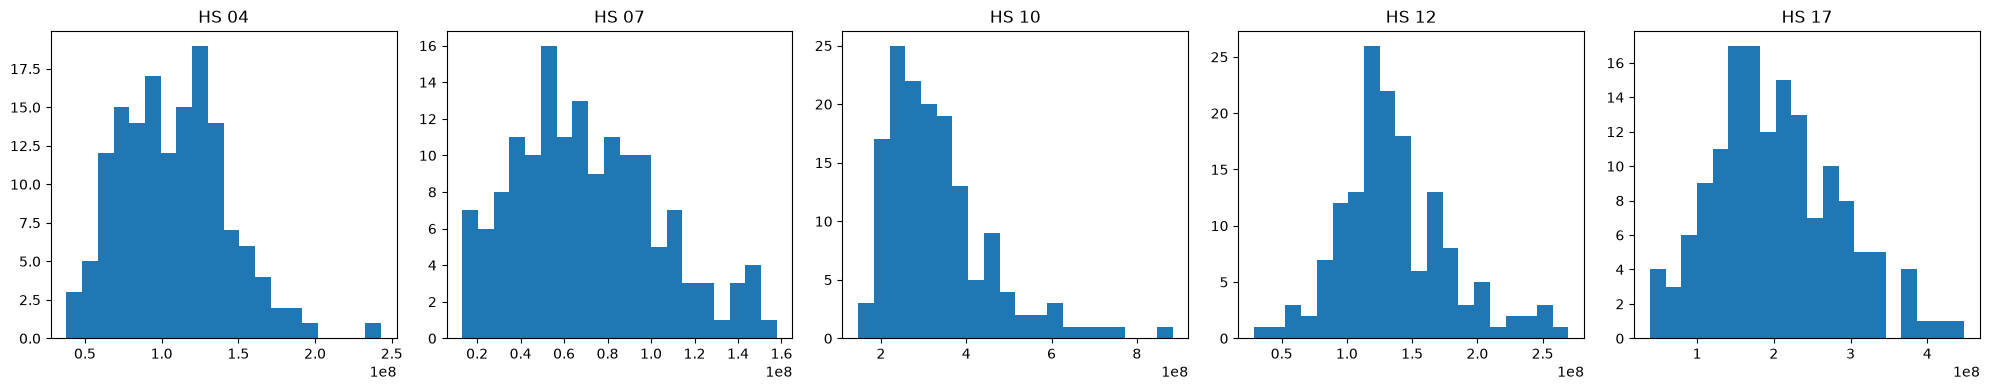

In [14]:
# Visualize the distribution of import values for each HS code
hs_list = sorted(df['HS_Code'].unique())
fig, axes = plt.subplots(1, len(hs_list), figsize=(20,4))

for ax, hs in zip(axes, hs_list):
    data_hs = df[df['HS_Code']==hs]['Import_Value']
    ax.hist(data_hs, bins=20)
    ax.set_title(f'HS {hs}')

plt.tight_layout()
plt.show()

* All commodities are right-skewed to varying degrees
* HS 10 has a high skewness of 1.54, far above other commodities, kurtosis of 3.27 also indicates the potential for outliers that pull the distribution to the right. Therefore, HS 10 is a strong candidate for a log-transform that can help stabilize the distribution before modeling

### Data Quality Check

In [15]:
# Check for missing values in the dataset
df.isna().sum()

Period          0
HS_Code         0
Import_Value    0
dtype: int64

In [16]:
# Check for duplicates
df.duplicated(subset=['Period','HS_Code']).sum()

np.int64(0)

In [17]:
# Check for missing periods for each HS code
expected_periods = pd.date_range(start='2014-01-01', end='2026-05-01', freq='MS')
for hs in df['HS_Code'].unique():
    actual_periods = set(df[df['HS_Code'] == hs]['Period'])
    missing = set(expected_periods) - actual_periods
    if missing:
        print(f"HS {hs} — missing periods: {sorted(missing)}")
    else:
        print(f"HS {hs} — complete, no gaps")

HS 04 — complete, no gaps
HS 07 — complete, no gaps
HS 10 — complete, no gaps
HS 12 — complete, no gaps
HS 17 — complete, no gaps


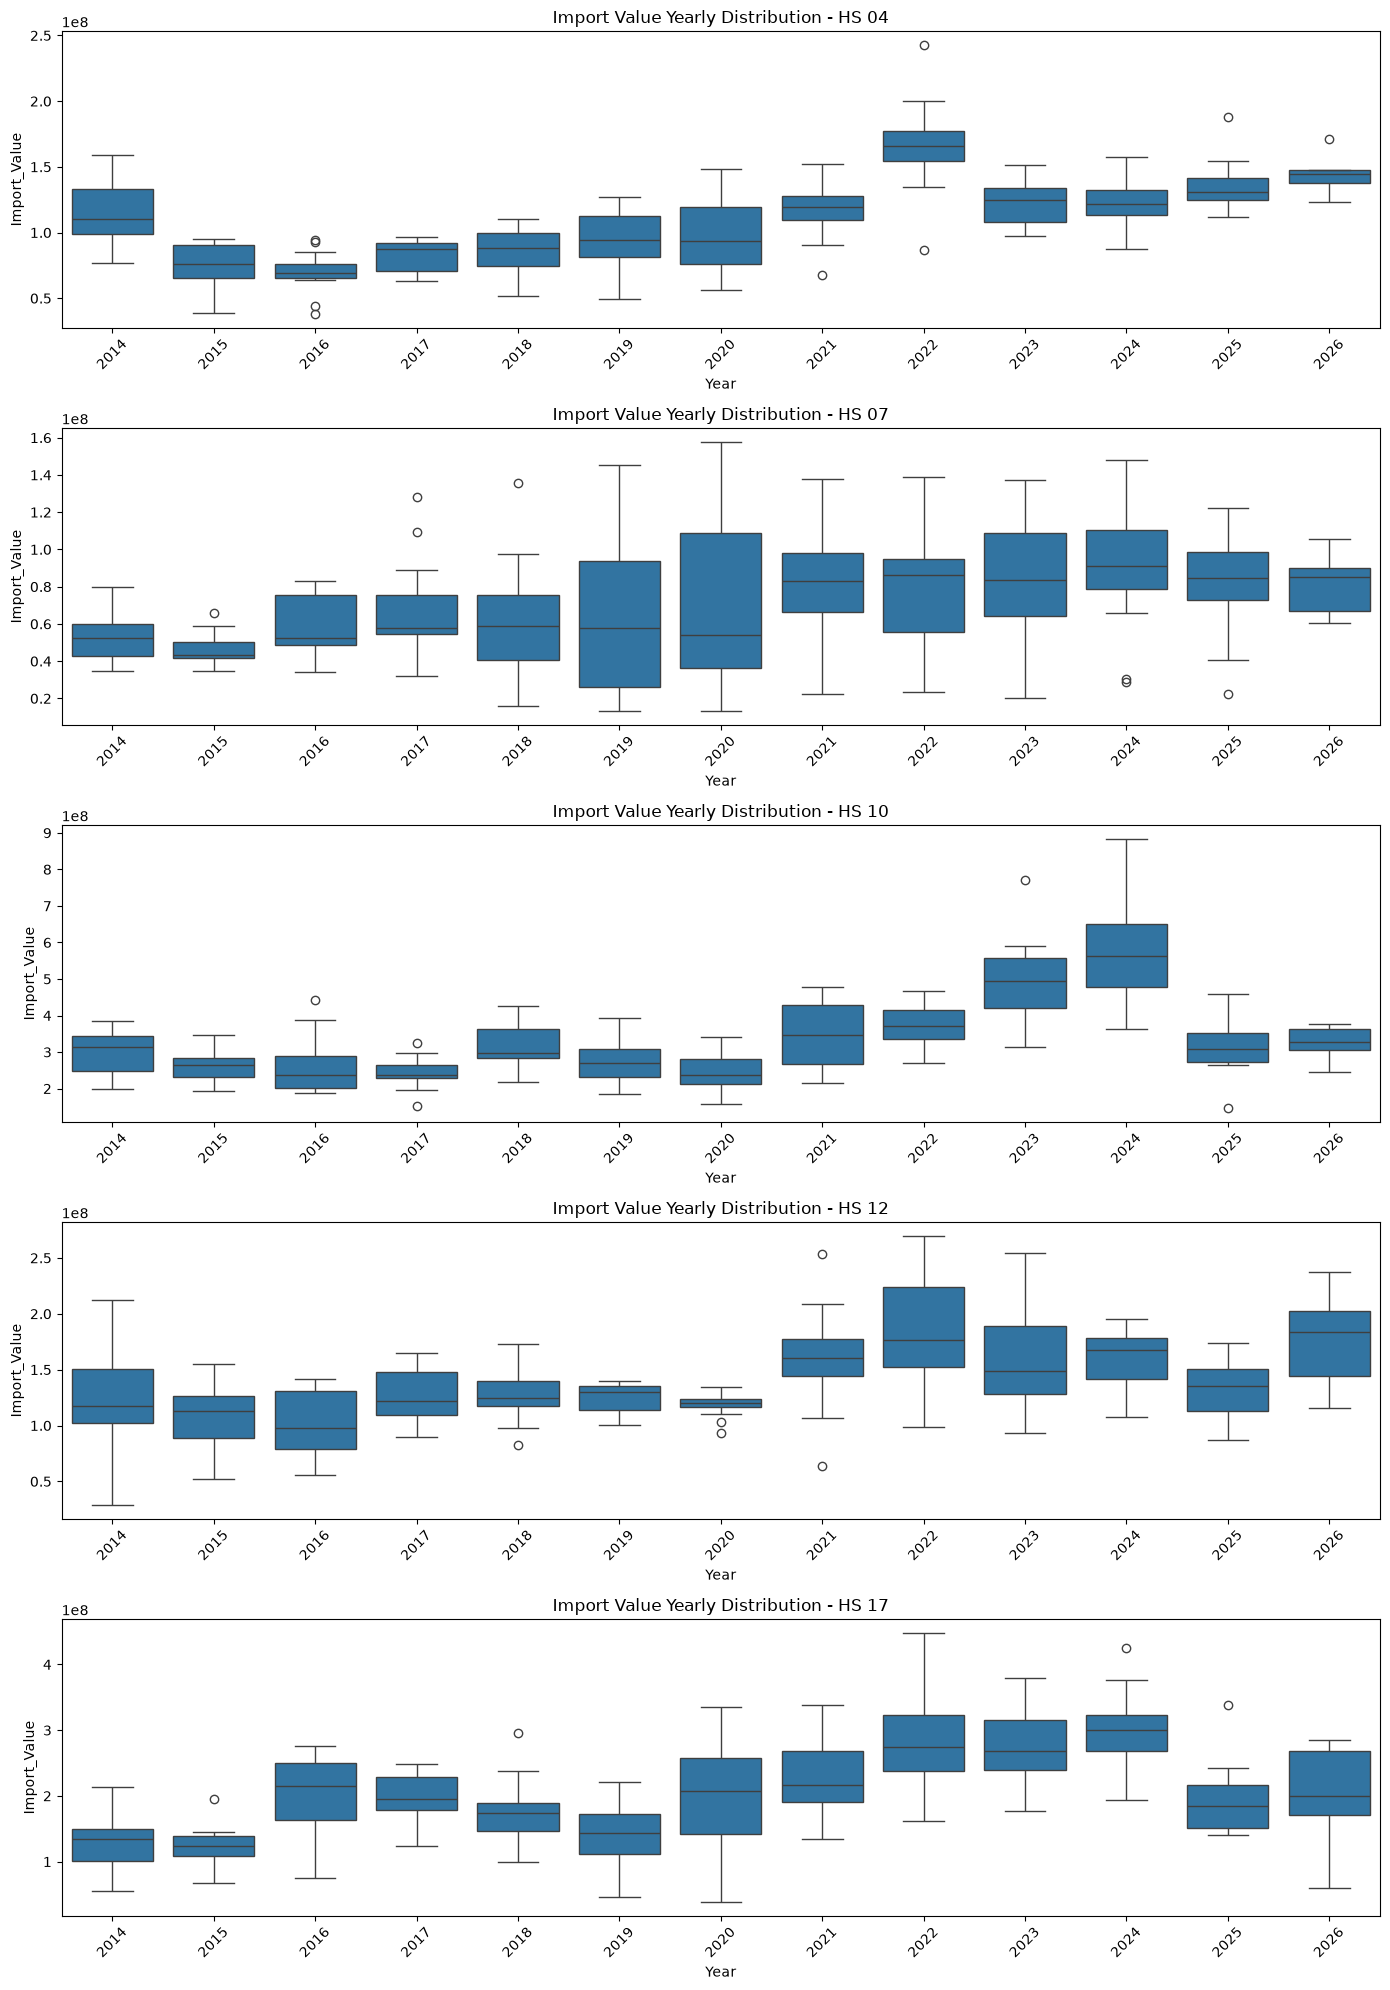

In [18]:
# Check outliers using boxplots
df['Year'] = df['Period'].dt.year
hs_list = df['HS_Code'].unique()
fig, axes = plt.subplots(len(hs_list), 1, figsize=(14, 4*len(hs_list)))

for ax, hs in zip(axes, hs_list):
    data_hs = df[df['HS_Code'] == hs]
    sns.boxplot(data=data_hs, x='Year', y='Import_Value', ax=ax)
    ax.set_title(f'Import Value Yearly Distribution - HS {hs}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Exploratory Data Analysis

#### Import Value Trend

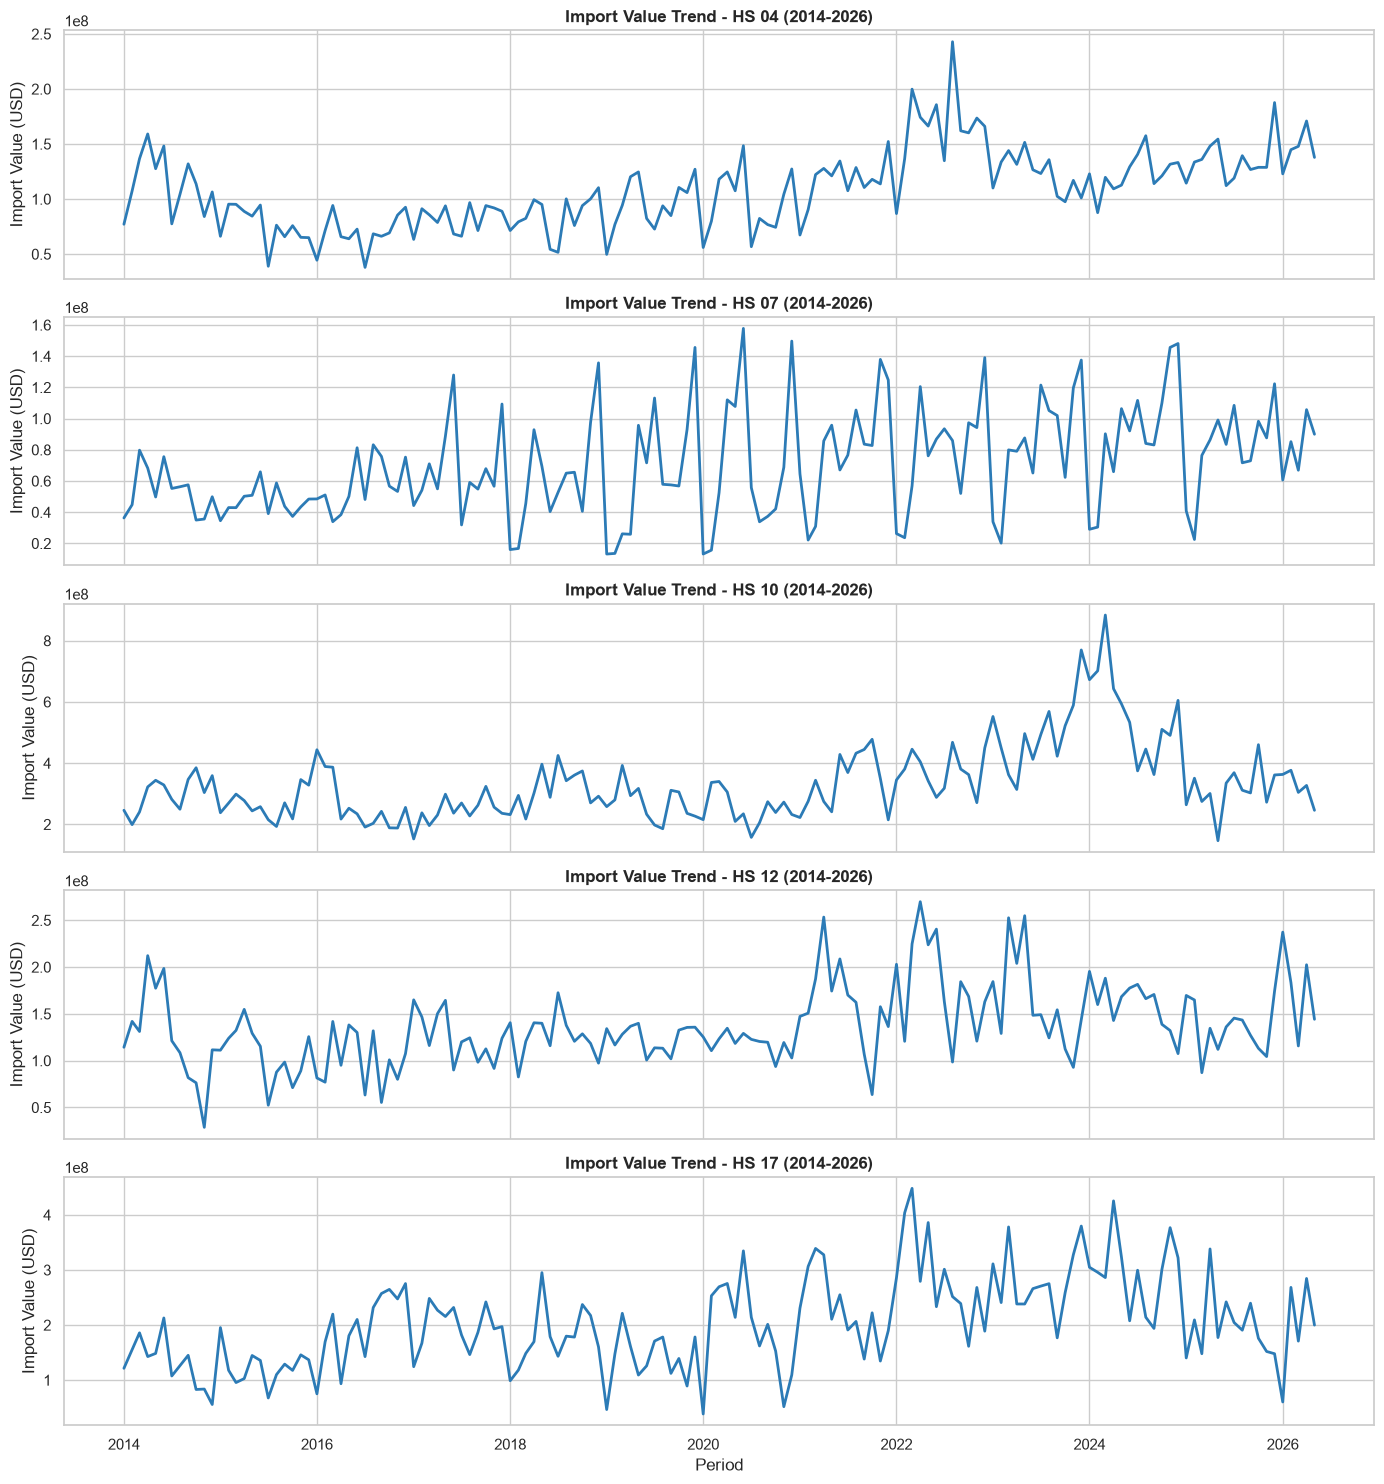

In [19]:
# Visualize the trend of import values over time for each HS code
df = df.sort_values(by=['HS_Code', 'Period'])

sns.set_theme(style="whitegrid")
hs_list = sorted(df['HS_Code'].unique())

# Individual Subplots
# sharex=True aligns the x-axis timeline perfectly across all plots
fig, axes = plt.subplots(len(hs_list), 1, figsize=(14, 3 * len(hs_list)), sharex=True)

for ax, hs in zip(axes, hs_list):
    data_hs = df[df['HS_Code'] == hs]

    # Plot the line chart for each specific HS code
    sns.lineplot(data=data_hs, x='Period', y='Import_Value', ax=ax, linewidth=2, color='#2c7bb6')

    # Formatting for professional appearance
    ax.set_title(f'Import Value Trend - HS {hs} (2014-2026)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Import Value (USD)')
    ax.set_xlabel('Period')

plt.tight_layout()
plt.show()

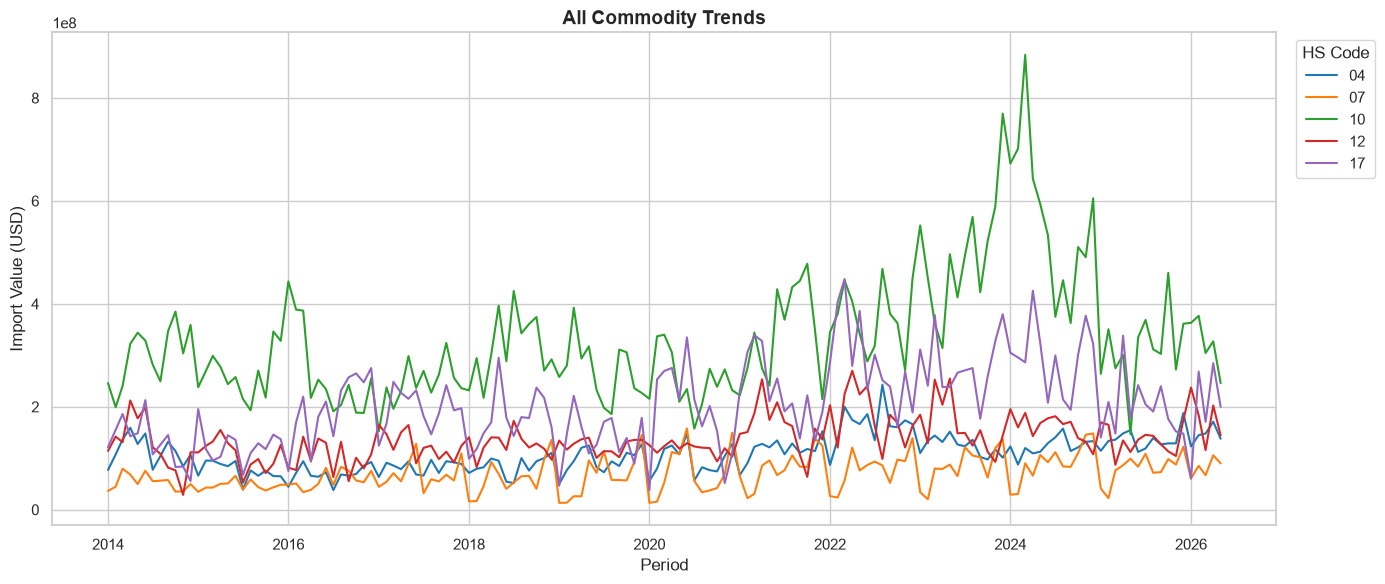

In [21]:
# Combined Overlay Plot
plt.figure(figsize=(14, 6))

# The 'hue' parameter automatically colors the lines by HS code
sns.lineplot(data=df, x='Period', y='Import_Value', hue='HS_Code', linewidth=1.5, palette='tab10')

plt.title('All Commodity Trends', fontsize=14, fontweight='bold')
plt.ylabel('Import Value (USD)')
plt.xlabel('Period')

# Place the legend outside the plot so it doesn't cover the data
plt.legend(title='HS Code', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

From the line plot, it can be seen that the import value data is non-stationary because it does not have a constant mean and variance over time. Classical linear models require differencing to stabilize the data. This line plot indicates a pattern of seasonality and cyclicality.

#### Year-over-Year Growth Rate

In [22]:
# Year-over-Year Growth Rate
# Import value per year per commodity
yearly = df.groupby(['HS_Code','Year'])['Import_Value'].sum().reset_index()

# Growth rate per komoditas
yearly['YoY_Growth_%'] = yearly.groupby('HS_Code')['Import_Value'].pct_change() * 100
yearly = yearly[yearly['Year'] < 2026]

pd.set_option('display.max_rows', None)
yearly

,HS_Code,Year,Import_Value,YoY_Growth_%
0,04,2014,1.374223e+09,NaN
1,04,2015,9.117069e+08,-33.656567
2,04,2016,8.324027e+08,-8.698422
3,04,2017,9.905174e+08,18.994976
4,04,2018,1.014479e+09,2.419119
5,04,2019,1.143428e+09,12.710815
6,04,2020,1.156623e+09,1.154031
7,04,2021,1.394290e+09,20.548316
8,04,2022,1.989220e+09,42.669021
9,04,2023,1.474328e+09,-25.884109


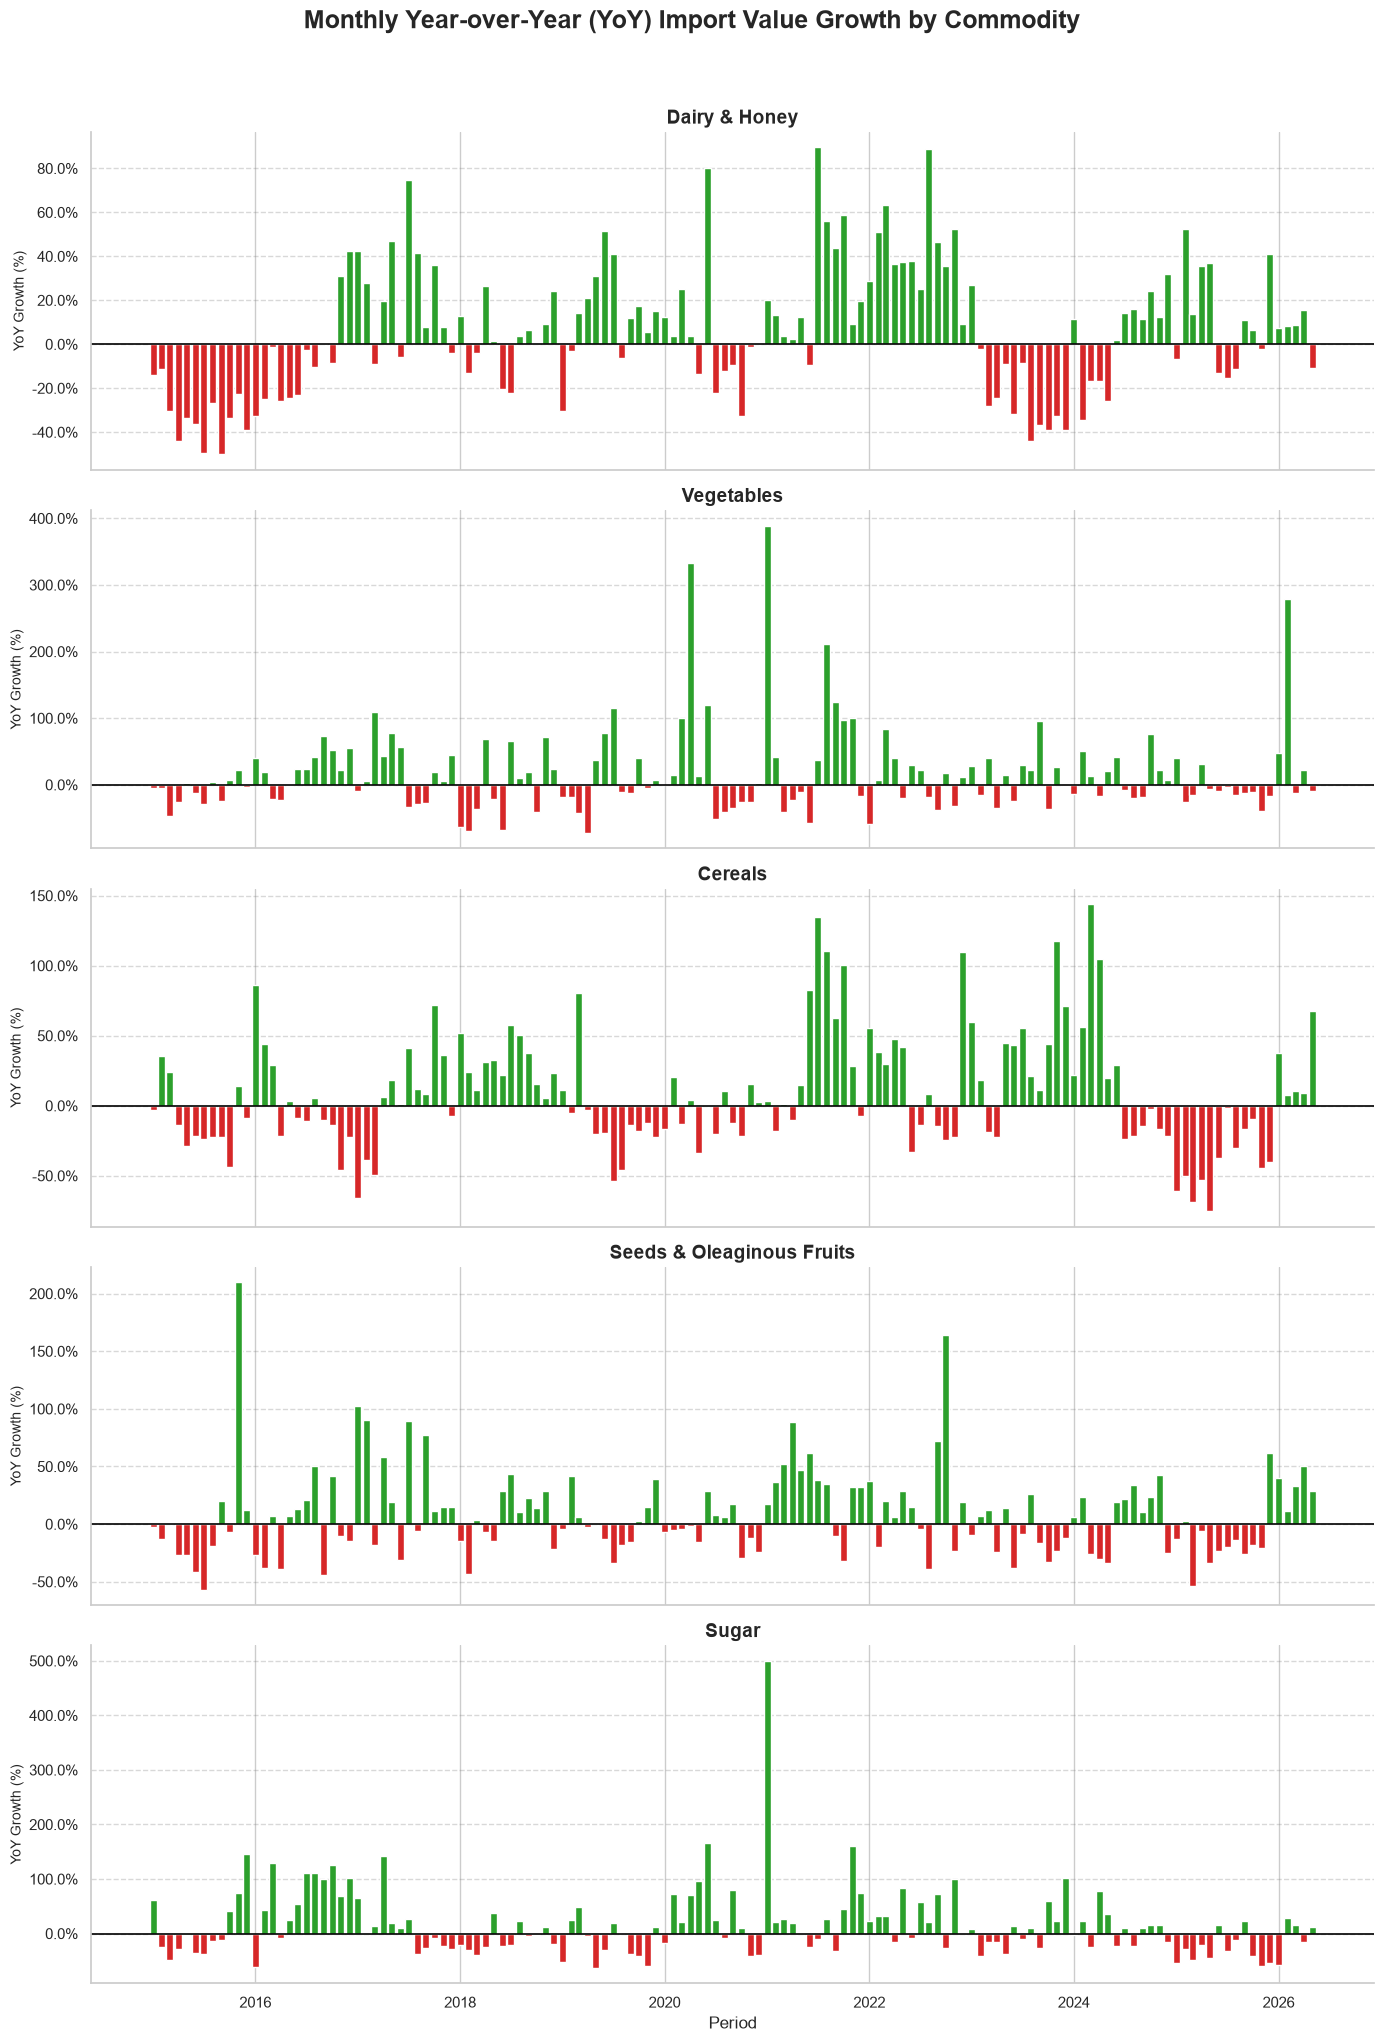

In [23]:
# Calculate YoY exactly as Streamlit does
# Ensure data is sorted chronologically per commodity before calculating pct_change
df_sorted = df.sort_values(by=['HS_Code', 'Period']).copy()
df_sorted['YoY_Growth_%'] = df_sorted.groupby('HS_Code')['Import_Value'].pct_change(periods=12) * 100

# Map HS Codes to readable names
hs_mapping = {
    '04': 'Dairy & Honey',
    '07': 'Vegetables',
    '10': 'Cereals',
    '12': 'Seeds & Oleaginous Fruits',
    '17': 'Sugar'
}
df_sorted['Commodity'] = df_sorted['HS_Code'].map(hs_mapping)

# Setup the Subplots Grid (5 rows, 1 column)
commodities = list(hs_mapping.values())
fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)

# Iterate through each commodity and plot its own bar chart
for i, commodity in enumerate(commodities):
    ax = axes[i]
    
    # Filter for the specific commodity and drop the first 12 months (which are NaN)
    df_single = df_sorted[df_sorted['Commodity'] == commodity]
    
    # Apply Streamlit's Green/Red conditional coloring logic
    bar_colors = ['#2ca02c' if val >= 0 else '#d62728' for val in df_single['YoY_Growth_%']]
    
    # Plot the monthly bars
    ax.bar(df_single['Period'], df_single['YoY_Growth_%'], color=bar_colors, width=25)
    
    # Styling for each subplot
    ax.axhline(0, color='black', linewidth=1.2, linestyle='-')
    ax.set_title(f'{commodity}', fontsize=14, fontweight='bold')
    ax.set_ylabel('YoY Growth (%)', fontsize=10)
    
    # Format Y-axis to percentages
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.1f}%'))
    
    # Add background gridlines
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.3)

# Layout Adjustments
plt.xlabel('Period', fontsize=12)
sns.despine()

plt.suptitle('Monthly Year-over-Year (YoY) Import Value Growth by Commodity', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The graph shows high volatility (rapid ups and downs over a wide range in a short time). This shows that the value of imports is vulnerable to macroeconomic shocks (events or sudden changes that affect the economy), so that classical statistical models often have difficulty making predictions.

#### Seasonal Decomposition

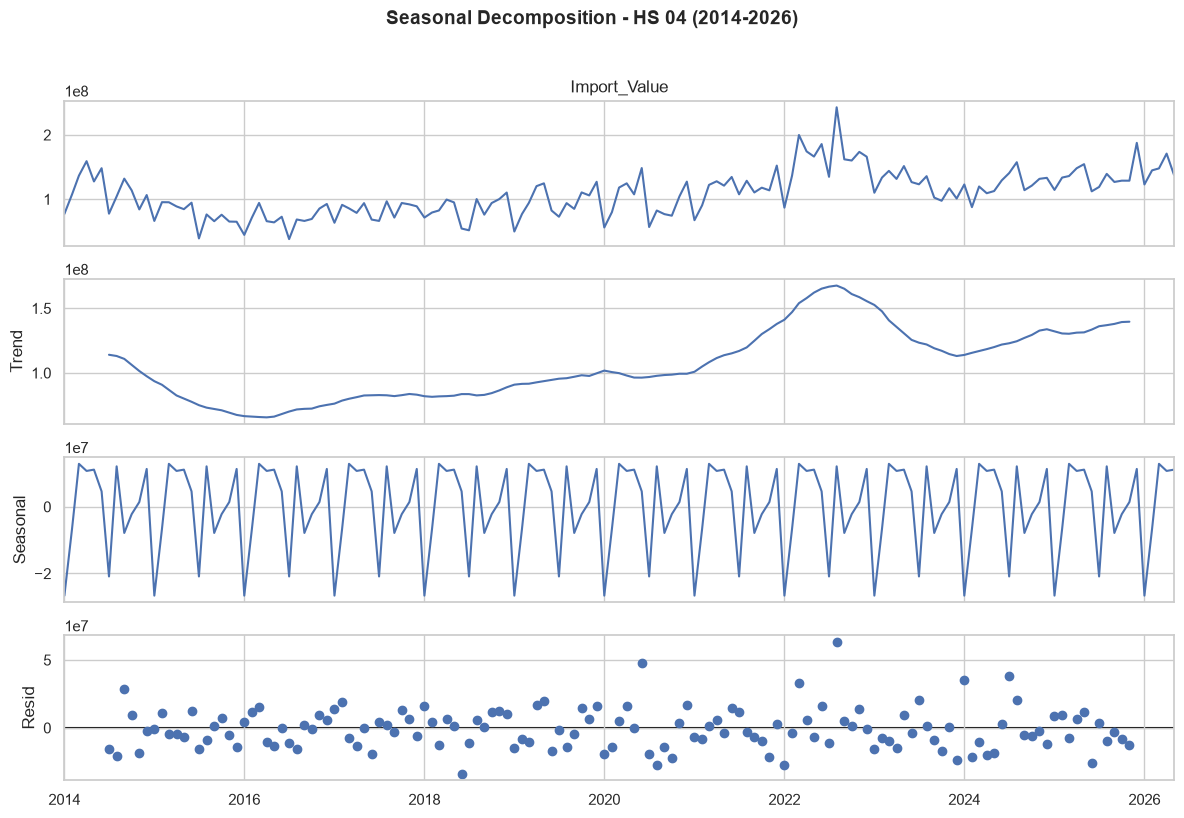

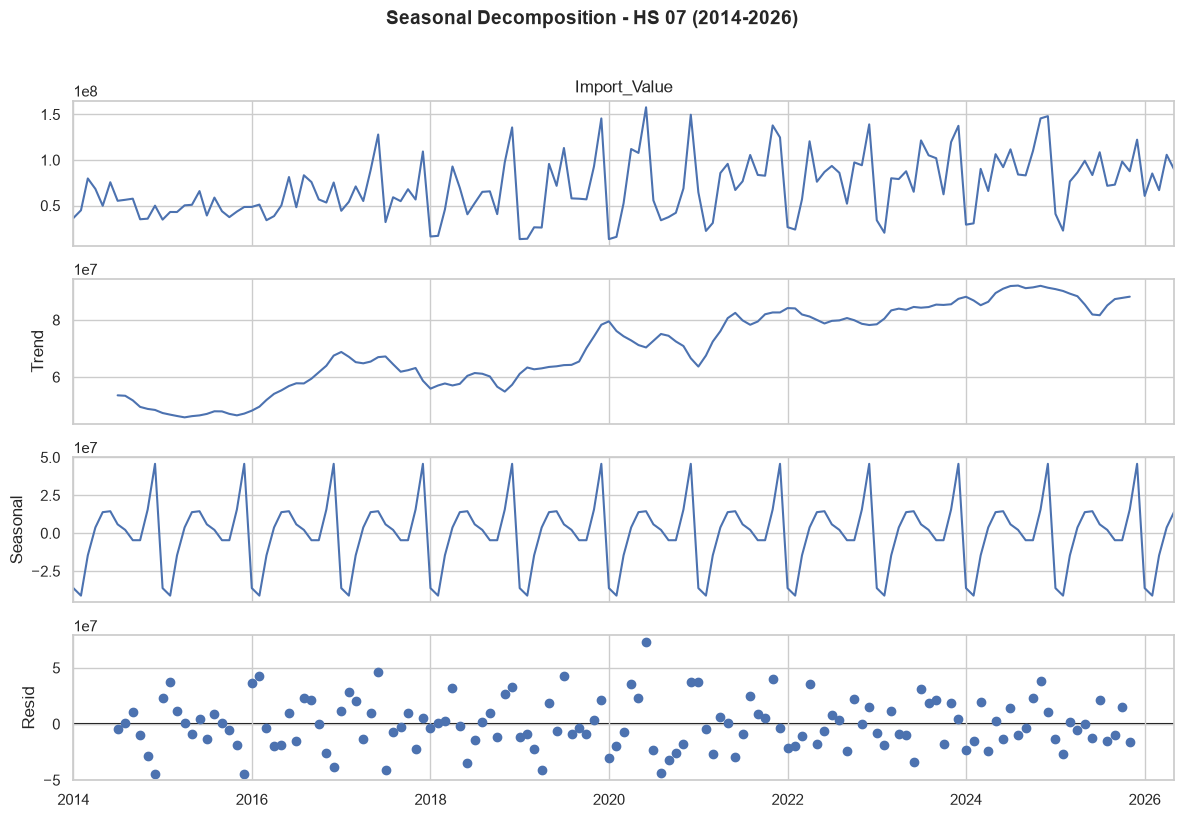

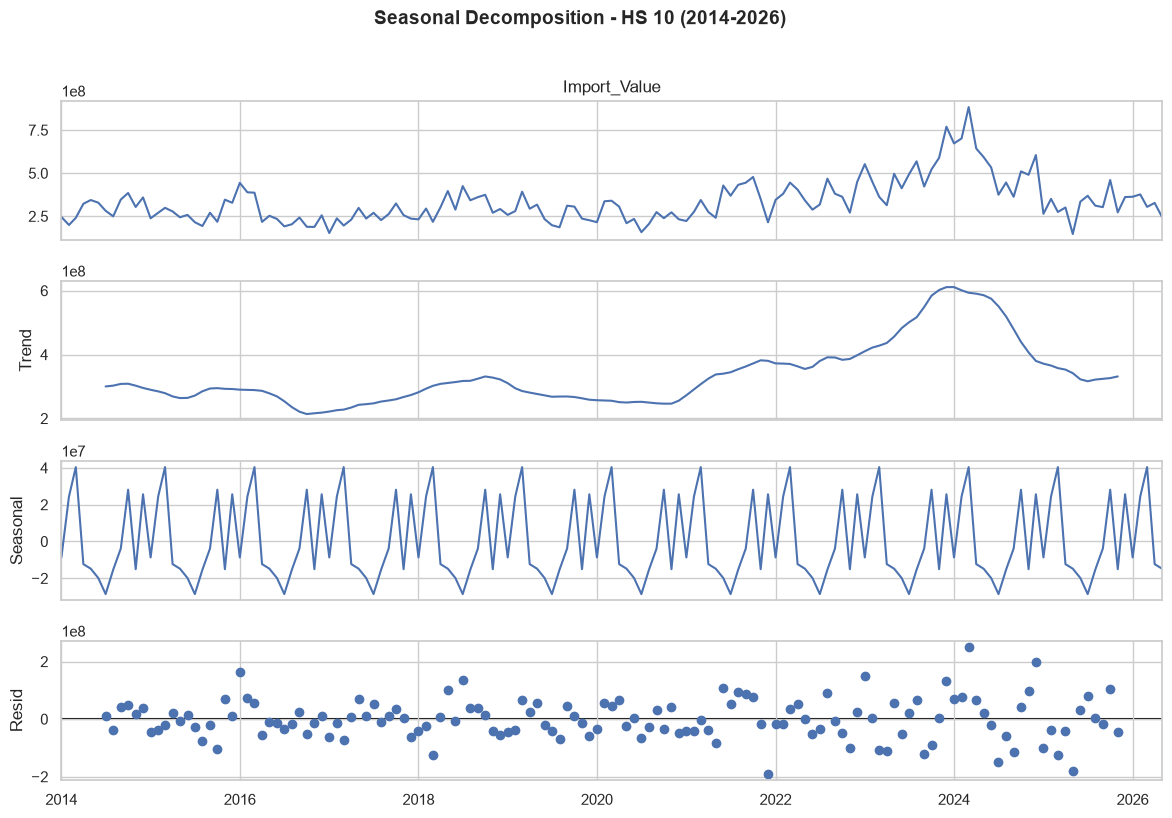

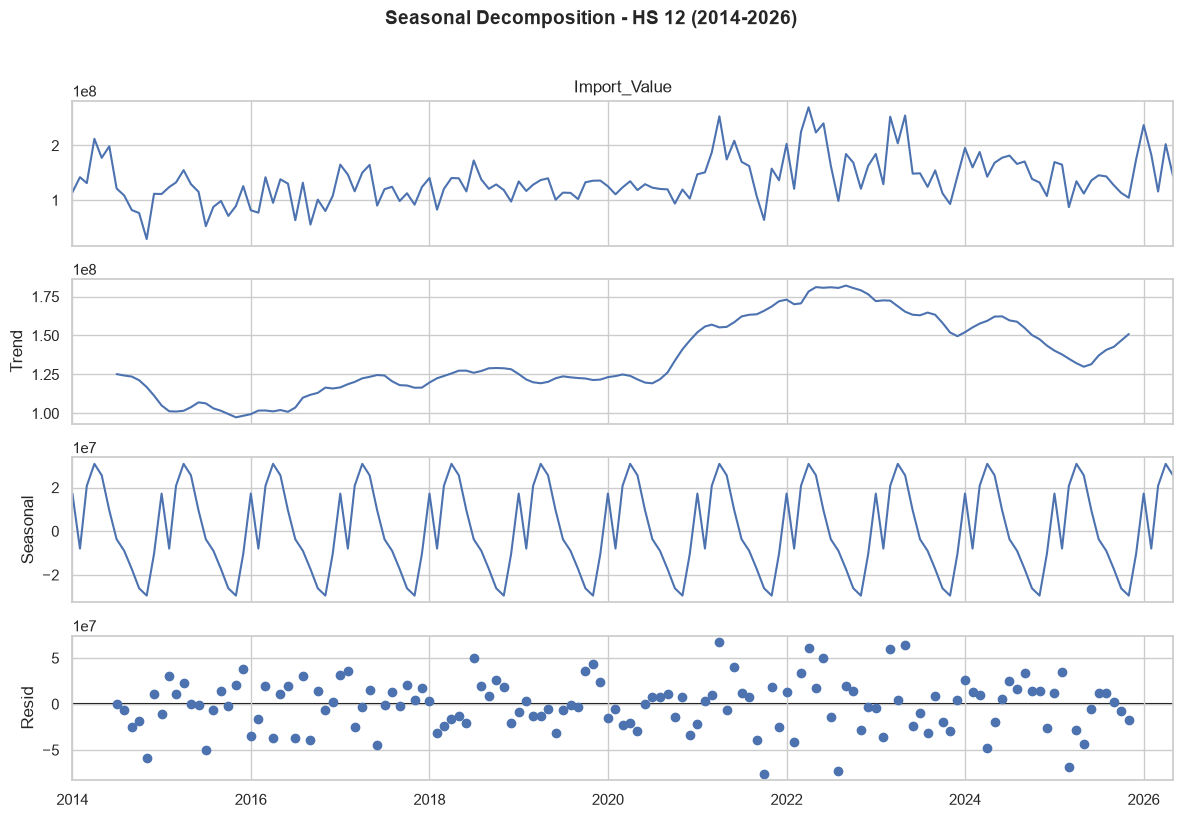

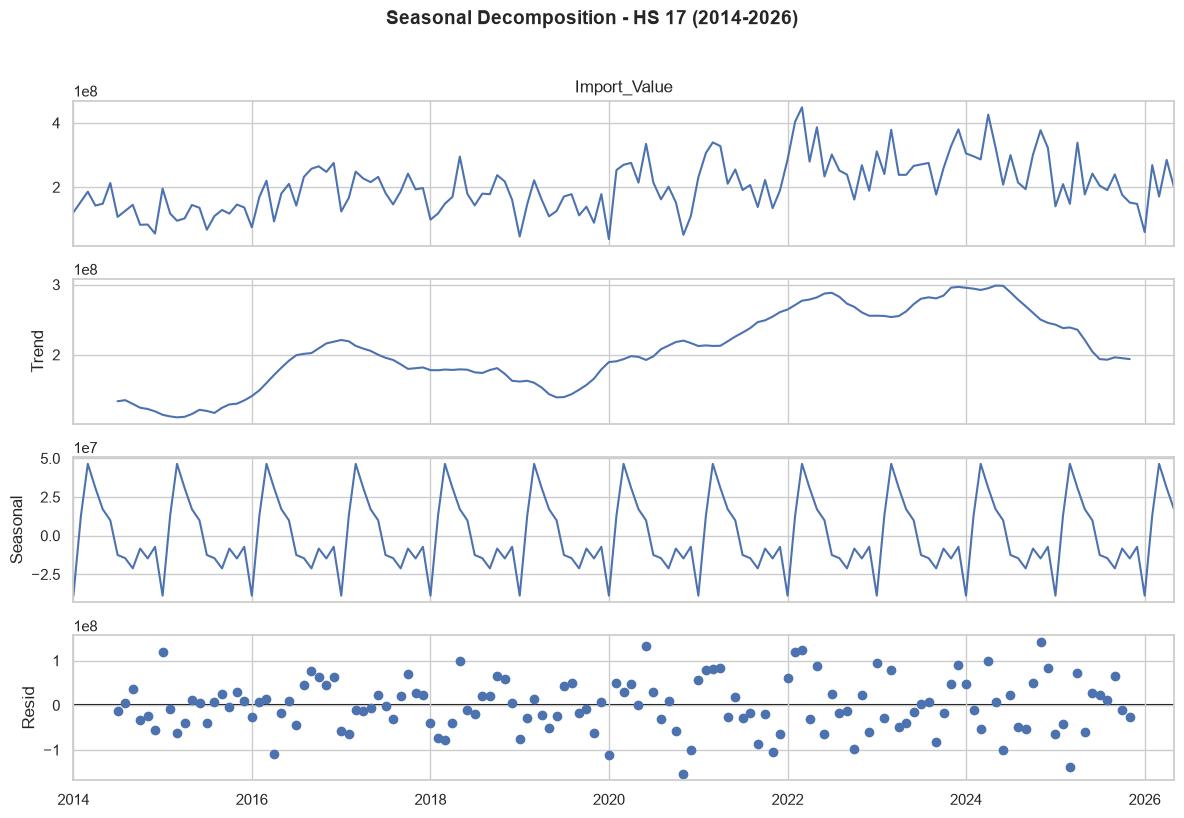

In [24]:
hs_list = sorted(df['HS_Code'].unique())

for hs in hs_list:
    data_hs = df[df['HS_Code'] == hs].copy()
    data_hs.set_index('Period', inplace=True)
    data_hs = data_hs.asfreq('MS')

    # Perform the seasonal decomposition
    # We use period=12 because the data is monthly and we expect annual seasonality
    decomposition = seasonal_decompose(data_hs['Import_Value'], model='additive', period=12)

    fig = decomposition.plot()
    fig.set_size_inches(12, 8)

    # Add a custom title and adjust spacing
    fig.suptitle(f'Seasonal Decomposition - HS {hs} (2014-2026)', fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

This plot confirms the existence of high volatility and non-stationarity in all food raw materials. The trend shows that the time based mean is not constant which indicates this data is non-stationary. The seasonal component shows the existence of seasonality patterns every 12 months for each commodity which confirms the use of seasonal autoregressive and moving average parameters in the SARIMA model. The residual analysis results also show the limitations of classical statistical methods on this dataset due to non-constant noise variance (heteroskedasticity). This is the reason to use machine learning as a solution to handle this complex noise.

#### Stationarity test

In [25]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Initialize a list to store the formal results for your journal table
adf_results = []
hs_list = sorted(df['HS_Code'].unique())

for hs in hs_list:
    # Extract the time series for the specific commodity
    data_hs = df[df['HS_Code'] == hs]['Import_Value'].dropna()

    # Run ADF on the original raw data (d = 0)
    result_raw = adfuller(data_hs)
    p_val_raw = result_raw[1]

    # Check if the raw data is already stationary (p-value < 0.05)
    if p_val_raw < 0.05:
        d = 0
        final_p_val = p_val_raw
        status = "Stationer (Level 0)"
    else:
        # Apply 1st order differencing (d = 1)
        data_diff1 = data_hs.diff().dropna()
        result_diff1 = adfuller(data_diff1)
        p_val_diff1 = result_diff1[1]

        if p_val_diff1 < 0.05:
            d = 1
            final_p_val = p_val_diff1
            status = "Stationer (Differencing 1)"
        else:
            # Apply 2nd order differencing (d = 2)
            # It is extremely rare for economic data to need more than d=2
            data_diff2 = data_diff1.diff().dropna()
            result_diff2 = adfuller(data_diff2)
            p_val_diff2 = result_diff2[1]

            d = 2
            final_p_val = p_val_diff2
            status = "Stationer (Differencing 2)"

    # Save the results for this commodity
    adf_results.append({
        'Kode HS': hs,
        'P-Value (Data Asli)': f"{p_val_raw:.4f}",
        'Ordo Differencing (d)': d,
        'P-Value (Final)': f"{final_p_val:.4f}",
        'Kesimpulan': status
    })

# Convert the results into a clean Pandas DataFrame
df_adf_summary = pd.DataFrame(adf_results)
print(df_adf_summary.to_string(index=False))

Kode HS P-Value (Data Asli)  Ordo Differencing (d) P-Value (Final)                 Kesimpulan
     04              0.5347                      1          0.0207 Stationer (Differencing 1)
     07              0.7498                      1          0.0000 Stationer (Differencing 1)
     10              0.0124                      0          0.0124        Stationer (Level 0)
     12              0.6137                      1          0.0000 Stationer (Differencing 1)
     17              0.3214                      1          0.0023 Stationer (Differencing 1)


From the results of this stationary test, it was found that 4 commodities have probability values ​​that are far above the non-stationary limit so that they require first level differencing to become stationary. Meanwhile, for HS 10, even though volatility is high, HS 10 has a tendency to return to its average value in the long term, so for SARIMA modeling, HS 10 will use the parameter d=0.

The results of this test also provide strong theoretical justification for the use of machine learning algorithms such as XGBoost as a comparison model. Tree-based models such as XGBoost have the advantage of not being tied to data stationarity assumptions. This algorithm can directly process highly volatile time series data, making it a much more efficient and robust solution for dealing with complex real-world economic data.

#### ACF & PACF Plot

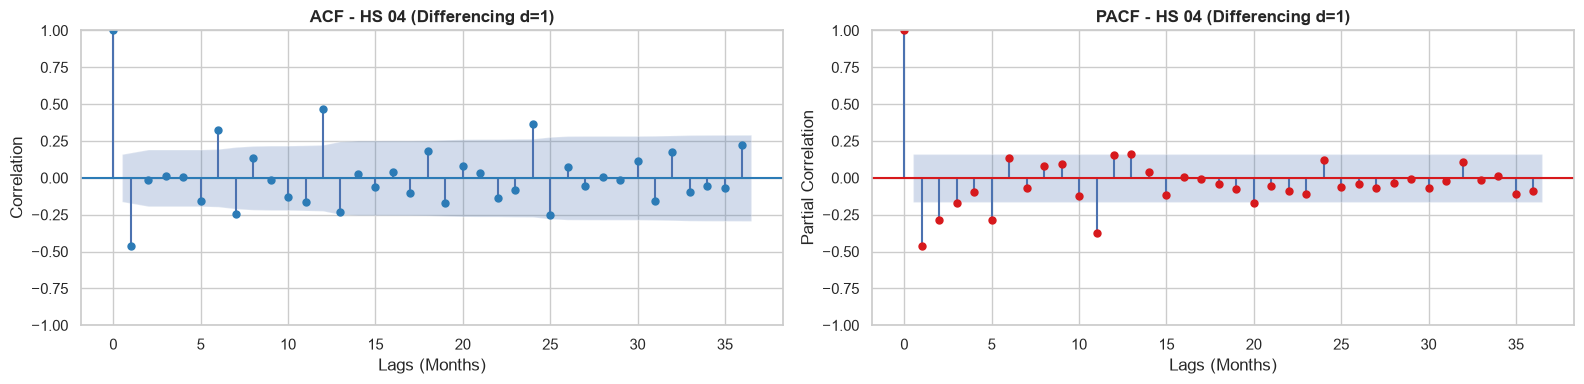

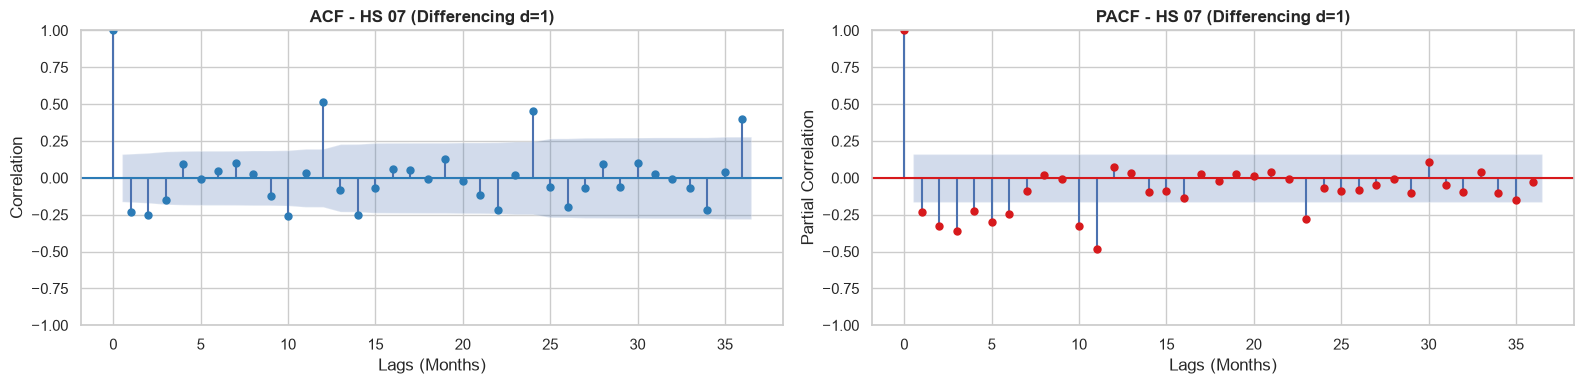

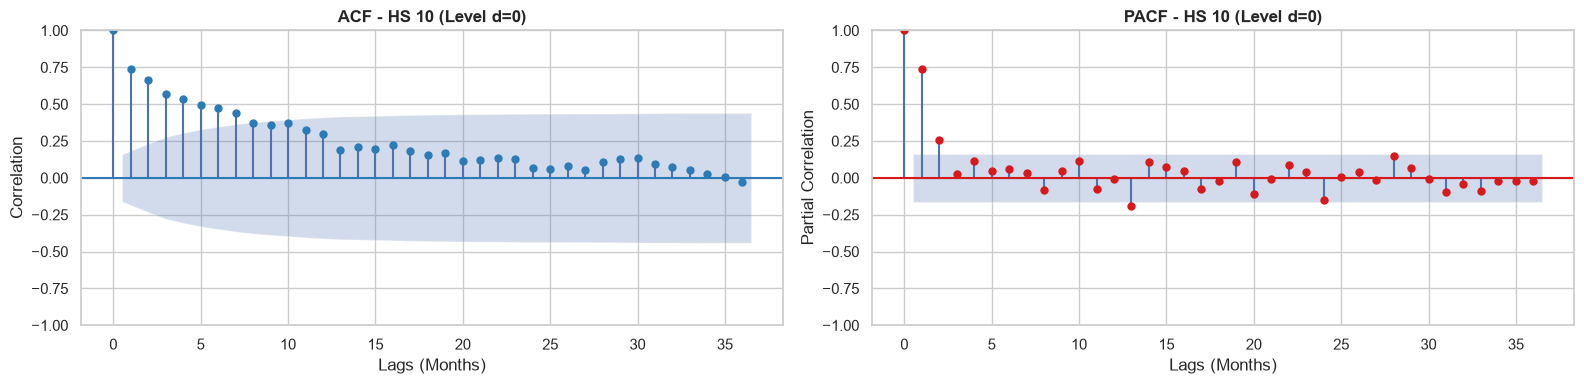

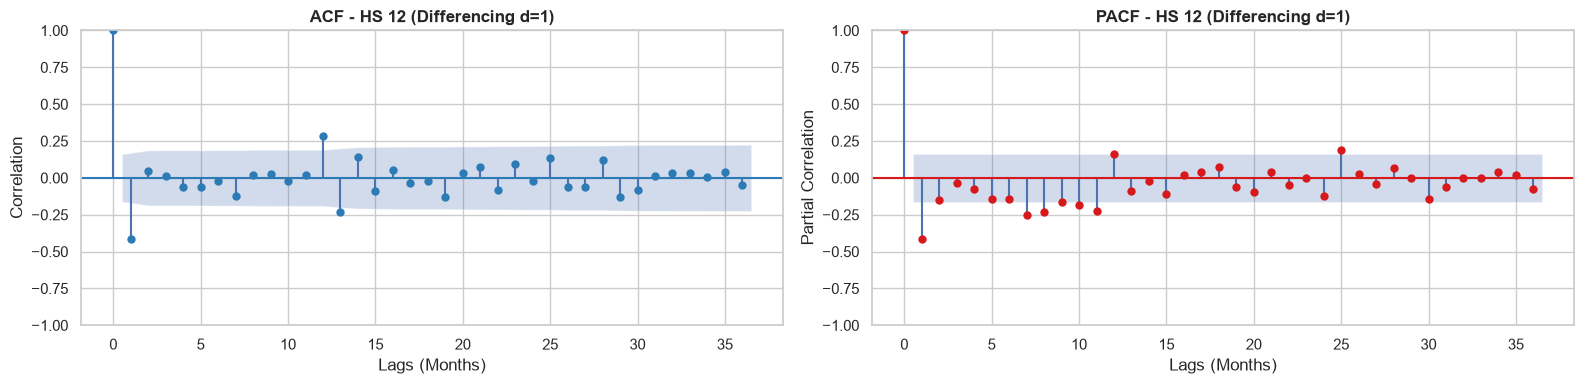

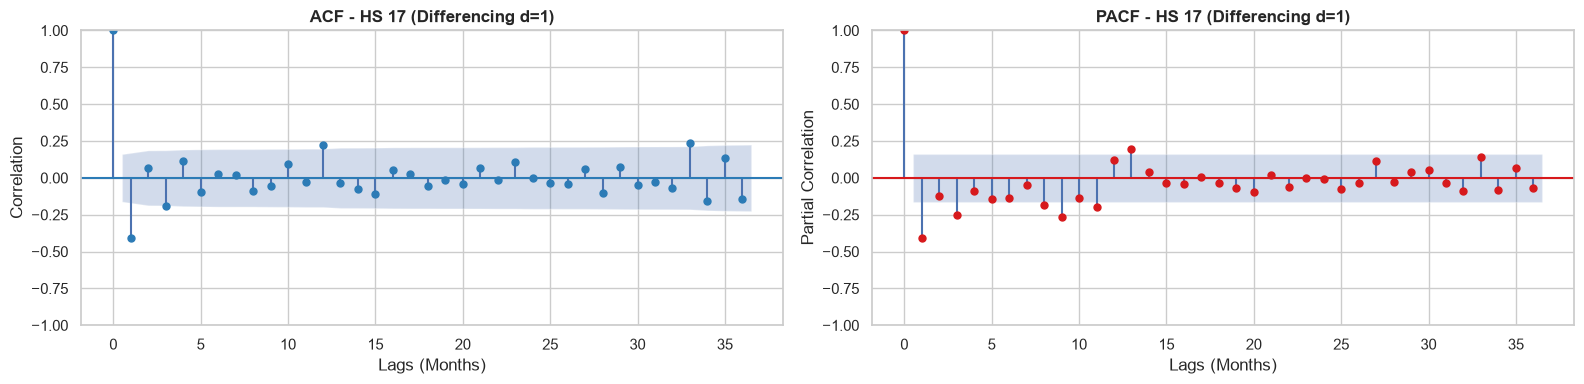

In [26]:
# Define the differencing order (d) based on your ADF test results
d_orders = {'04': 1, '07': 1, '10': 0, '12': 1, '17': 1}
hs_list = sorted(df['HS_Code'].unique())

for hs in hs_list:
    # Extract the time series for the specific commodity
    data_hs = df[df['HS_Code'] == hs].set_index('Period')['Import_Value']

    # Apply the correct differencing dynamically
    d = d_orders[hs]
    if d == 1:
        data_stationary = data_hs.diff().dropna()
        title_suffix = "(Differencing d=1)"
    else:
        data_stationary = data_hs.dropna()
        title_suffix = "(Level d=0)"

    # Create subplots: 1 row, 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Generate ACF Plot (determines 'q' and 'Q')
    # lags=36 allows us to see 3 full years of seasonality (12, 24, 36)
    plot_acf(data_stationary, lags=36, ax=axes[0], color='#2c7bb6')
    axes[0].set_title(f'ACF - HS {hs} {title_suffix}', fontweight='bold')
    axes[0].set_xlabel('Lags (Months)')
    axes[0].set_ylabel('Correlation')

    # Generate PACF Plot (determines 'p' and 'P')
    plot_pacf(data_stationary, lags=36, ax=axes[1], color='#d7191c', method='ywm')
    axes[1].set_title(f'PACF - HS {hs} {title_suffix}', fontweight='bold')
    axes[1].set_xlabel('Lags (Months)')
    axes[1].set_ylabel('Partial Correlation')

    plt.tight_layout()
    plt.show()

ACF and PACF analyzes were carried out on stationary data to identify the Autoregressive ($p$) and Moving Average ($q$) parameters in the SARIMA model. From this plot, the Cereal commodity (HS 10) indicates the characteristics of a pure Autoregressive model, namely AR(1).

In contrast, for other commodities that have gone through a first level differencing process ($d=1$) such as Milk (HS 04) and Vegetables (HS 07), there is a significant negative spike in the initial lag in both plots, which suggests the need for a combination of lower order parameters for $p$ and $q$.

In addition to the non-seasonal component, the ACF and PACF plots also validate the existence of a seasonal cycle previously detected in the decomposition at 12-month increments (lag 12 and lag 24). This phenomenon provides confirmation for setting seasonal frequency parameters ($m=12$) as well as incorporating Seasonal Autoregressive ($P$) and Seasonal Moving Average ($Q$) components into the basic SARIMA configuration.

## Data Preparation 2

### Handling Skewness & Kurtosis

In [27]:
# Check log-transform
df['log_Import_Value'] = np.log(df['Import_Value'])

skew_kurt_log = df.groupby('HS_Code')['log_Import_Value'].agg(
    skewness=lambda x: x.skew(),
    kurtosis=lambda x: x.kurt()
).reset_index()

skew_kurt_log

,HS_Code,skewness,kurtosis
0,04,-0.393390,0.108935
1,07,-0.731760,0.354812
2,10,0.456097,0.181730
3,12,-0.764836,2.832682
4,17,-0.821141,1.040098


HS 10 and HS 04 improved compared to before, whereas the other commodities deteriorated; therefore, the log transform will be applied only to HS 10 and HS 04.

In [28]:
df.head()

,Period,HS_Code,Import_Value,Year,log_Import_Value
0,2014-01-01,04,77115100.0,2014,18.160810
1,2014-02-01,04,107389161.0,2014,18.491970
2,2014-03-01,04,136648208.0,2014,18.732920
3,2014-04-01,04,159130719.0,2014,18.885237
4,2014-05-01,04,127602341.0,2014,18.664429


### Train-Test Split

In [29]:
# Split the dataset into training and testing sets based on a specific date threshold
df['Period'] = pd.to_datetime(df['Period'])
train_df = df[df['Period'] <= '2024-12-01'].copy()
test_df = df[df['Period'] > '2024-12-01'].copy()

print("=== Split Dataset Summary ===")
print(f"Train Rows totals: {train_df.shape[0]}")
print(f"Test Rows totals : {test_df.shape[0]}\n")
print(f"Train Range : {train_df['Period'].min().strftime('%Y-%m')} hingga {train_df['Period'].max().strftime('%Y-%m')}")
print(f"Test Range  : {test_df['Period'].min().strftime('%Y-%m')} hingga {test_df['Period'].max().strftime('%Y-%m')}\n")
print("=== Details ===")
for hs in sorted(df['HS_Code'].unique()):
    train_hs_count = train_df[train_df['HS_Code'] == hs].shape[0]
    test_hs_count = test_df[test_df['HS_Code'] == hs].shape[0]
    print(f"HS {hs} -> Train: {train_hs_count} months | Test: {test_hs_count} months")

=== Split Dataset Summary ===
Train Rows totals: 660
Test Rows totals : 85

Train Range : 2014-01 hingga 2024-12
Test Range  : 2025-01 hingga 2026-05

=== Details ===
HS 04 -> Train: 132 months | Test: 17 months
HS 07 -> Train: 132 months | Test: 17 months
HS 10 -> Train: 132 months | Test: 17 months
HS 12 -> Train: 132 months | Test: 17 months
HS 17 -> Train: 132 months | Test: 17 months


## Modeling

In [30]:
warnings.filterwarnings("ignore")

def create_xgb_features(data):
    df_feat = data.copy()
    df_feat['Month'] = df_feat['Period'].dt.month
    df_feat['Lag_1'] = df_feat['log_Import_Value'].shift(1)
    df_feat['Lag_2'] = df_feat['log_Import_Value'].shift(2)
    df_feat['Lag_12'] = df_feat['log_Import_Value'].shift(12)
    return df_feat.dropna()

# Initialize global variables to store results across cells
hs_list = sorted(df['HS_Code'].unique())
d_orders = {'04': 1, '07': 1, '10': 0, '12': 1, '17': 1}
grand_metrics = {hs: {} for hs in hs_list}

print("Setup Complete")

Setup Complete


### SARIMA (Base Model)

In [42]:
print("=== Training SARIMA (Baseline) ===")
for hs in hs_list:
    data_hs = df[df['HS_Code'] == hs].sort_values('Period').reset_index(drop=True)
    train_df = data_hs[data_hs['Period'] <= '2024-12-01']
    test_df  = data_hs[data_hs['Period'] > '2024-12-01']

    y_train = train_df['log_Import_Value'].values
    y_test_real = np.exp(test_df['log_Import_Value'].values)

    # Train
    sarima_base = SARIMAX(y_train, order=(1, d_orders[hs], 1), seasonal_order=(1, 0, 1, 12))
    sarima_base_fit = sarima_base.fit(disp=False)

    # Forecast & Inverse Transform
    pred_log = sarima_base_fit.forecast(steps=len(test_df))
    pred_real = np.exp(pred_log)

    # Evaluate
    mape = mean_absolute_percentage_error(y_test_real, pred_real)
    grand_metrics[hs]['SARIMA_Base'] = round(mape * 100, 2)
    print(f"HS {hs} done.")

=== Training SARIMA (Baseline) ===
HS 04 done.
HS 07 done.
HS 10 done.
HS 12 done.
HS 17 done.


### SARIMA (Tuning Auto ARIMA)

In [43]:
print("=== Training Auto-ARIMA (Tuned) ===")
for hs in hs_list:
    data_hs = df[df['HS_Code'] == hs].sort_values('Period').reset_index(drop=True)
    train_df = data_hs[data_hs['Period'] <= '2024-12-01']
    test_df  = data_hs[data_hs['Period'] > '2024-12-01']

    y_train = train_df['log_Import_Value'].values
    y_test_real = np.exp(test_df['log_Import_Value'].values)

    # Train
    auto_model = pm.auto_arima(y_train, d=d_orders[hs], seasonal=True, m=12,
                               trace=False, error_action='ignore', suppress_warnings=True,
                               stepwise=True)

    # Forecast & Inverse Transform
    pred_log = auto_model.predict(n_periods=len(test_df))
    pred_real = np.exp(pred_log)

    # Evaluate
    mape = mean_absolute_percentage_error(y_test_real, pred_real)
    grand_metrics[hs]['SARIMA_Tuned'] = round(mape * 100, 2)
    print(f"HS {hs} done.")

=== Training Auto-ARIMA (Tuned) ===
HS 04 done.
HS 07 done.
HS 10 done.
HS 12 done.
HS 17 done.


### XGBoost (Base Model)

In [44]:
print("=== Training XGBoost (Baseline) ===")

# Fungsi ini mengembalikan logika persis seperti eksperimen asli Anda
def get_xgb_df(df, hs, is_logged):
    subset = df[df['HS_Code'] == hs].sort_values('Period')
    subset = subset.set_index('Period').asfreq('MS')

    y = np.log(subset['Import_Value']) if is_logged else subset['Import_Value']

    df_ml = pd.DataFrame({'y': y})
    df_ml['lag_1'] = df_ml['y'].shift(1)
    df_ml['lag_2'] = df_ml['y'].shift(2)
    df_ml['lag_12'] = df_ml['y'].shift(12)
    df_ml['month'] = df_ml.index.month
    return df_ml.dropna()

train_end_date = '2024-12-01'

for hs in hs_list:
    is_logged = hs in ['04', '10']
    df_ml = get_xgb_df(df, hs, is_logged)

    train_df = df_ml[:train_end_date]
    test_df = df_ml[pd.to_datetime(train_end_date) + pd.DateOffset(months=1):]

    X_train, y_train = train_df.drop(columns=['y']), train_df['y']
    X_test, y_test = test_df.drop(columns=['y']), test_df['y']

    # Train
    xgb_default = XGBRegressor(random_state=42)
    xgb_default.fit(X_train, y_train)

    # Forecast
    pred_default = xgb_default.predict(X_test)

    # Inverse transform if necessary
    test_actual = np.exp(y_test) if is_logged else y_test
    forecast_actual = np.exp(pred_default) if is_logged else pred_default

    # Evaluate
    mape = mean_absolute_percentage_error(test_actual, forecast_actual)
    grand_metrics[hs]['XGB_Base'] = round(mape * 100, 2)
    print(f"HS {hs} done.")

=== Training XGBoost (Baseline) ===
HS 04 done.
HS 07 done.
HS 10 done.
HS 12 done.
HS 17 done.


### XGBoost (Tuning GridSearchCV)

In [46]:
print("=== Training XGBoost (Tuned) ===")
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

train_end_date = '2024-12-01'

for hs in hs_list:
    is_logged = hs in ['04', '10']
    df_ml = get_xgb_df(df, hs, is_logged)

    train_df = df_ml[:train_end_date]
    test_df = df_ml[pd.to_datetime(train_end_date) + pd.DateOffset(months=1):]

    X_train, y_train = train_df.drop(columns=['y']), train_df['y']
    X_test, y_test = test_df.drop(columns=['y']), test_df['y']

    # Train & Tune
    xgb_base = XGBRegressor(random_state=42)
    grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, cv=tscv,
                               scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Forecast
    pred_tuned = grid_search.best_estimator_.predict(X_test)

    # Inverse transform if necessary
    test_actual = np.exp(y_test) if is_logged else y_test
    forecast_actual = np.exp(pred_tuned) if is_logged else pred_tuned

    # Evaluate
    mape = mean_absolute_percentage_error(test_actual, forecast_actual)
    grand_metrics[hs]['XGB_Tuned'] = round(mape * 100, 2)
    print(f"HS {hs} done.")

=== Training XGBoost (Tuned) ===
HS 04 done.
HS 07 done.
HS 10 done.
HS 12 done.
HS 17 done.


### XGBoost (Tuning GridSearchCV)

## MAPE Evaluation

In [47]:
final_df = pd.DataFrame.from_dict(grand_metrics, orient='index').reset_index()
final_df.rename(columns={'index': 'Kode_HS'}, inplace=True)

print("\n=== Metric Comparison Table (MAPE %) ===")
print(final_df.to_string(index=False))


=== Metric Comparison Table (MAPE %) ===
Kode_HS  SARIMA_Base  SARIMA_Tuned  XGB_Base  XGB_Tuned
     04        12.19         14.63     18.91      10.80
     07        17.88         19.19     22.36      21.37
     10        82.29         39.61     36.60      29.03
     12        27.93         29.87     28.69      19.96
     17        71.44         71.53     40.29      38.61
